# Student Performance Prediction

**Dataset:** Students Performance Dataset (~5000 students)

**Project Parts:**
- Part 1 : Data Cleaning & Exploratory Data Analysis (EDA)
- Part 2 : Model Training & Evaluation (Logistic Regression, Random Forest, XGBoost)
- Part 3 : NLP Logic — Entity Extraction from Egyptian Arabic

---

## PART 1 — Data Cleaning & EDA

### 1 - Imports & Setup

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import xgboost as xgb
from IPython.display import display
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### 2 - Load Data

In [74]:
df = pd.read_csv("Students Performance Dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


In [75]:
# Check duplicate rows
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [76]:
# Remove duplicates
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (5000, 23)


In [77]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   str    
 1   First_Name                  5000 non-null   str    
 2   Last_Name                   5000 non-null   str    
 3   Email                       5000 non-null   str    
 4   Gender                      5000 non-null   str    
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   str    
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 non-null   

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,21.048400,75.356076,70.701924,69.546552,74.956320,74.836214,49.963720,74.78305,71.652097,17.521140,5.507200,6.514420
std,1.989786,14.392716,17.436325,17.108996,14.404287,14.423848,28.989785,14.54243,7.230097,7.193035,2.886662,1.446155
min,18.000000,50.010000,40.000000,40.010000,50.000000,50.000000,0.000000,50.00000,50.602000,5.000000,1.000000,4.000000
25%,19.000000,62.945000,55.707500,54.697500,62.340000,62.357500,25.075000,61.97000,66.533875,11.500000,3.000000,5.300000
50%,21.000000,75.670000,70.860000,69.485000,75.090000,74.905000,49.600000,74.54000,71.696250,17.400000,6.000000,6.500000
75%,23.000000,87.862500,85.760000,83.922500,87.352500,87.292500,75.500000,87.63000,76.711625,23.700000,8.000000,7.800000
max,24.000000,100.000000,99.990000,99.980000,99.990000,99.990000,100.000000,100.00000,95.091500,30.000000,10.000000,9.000000


In [78]:
print('Info about dataset:')
print(f'  • {df.shape[0]} students (rows)')
print(f'  • {df.shape[1]} features (columns)')
print(f'  • {df.select_dtypes(include="number").shape[1]} numerical features')
print(f'  • {df.select_dtypes(include="object").shape[1]} categorical features')
print()
print('Target — Grade Distribution:')
print(df['Grade'].value_counts())

Info about dataset:
  • 5000 students (rows)
  • 23 features (columns)
  • 12 numerical features
  • 11 categorical features

Target — Grade Distribution:
Grade
C    2307
D    1760
B     638
F     279
A      16
Name: count, dtype: int64


### 3 - Exploratory Data Analysis (EDA)

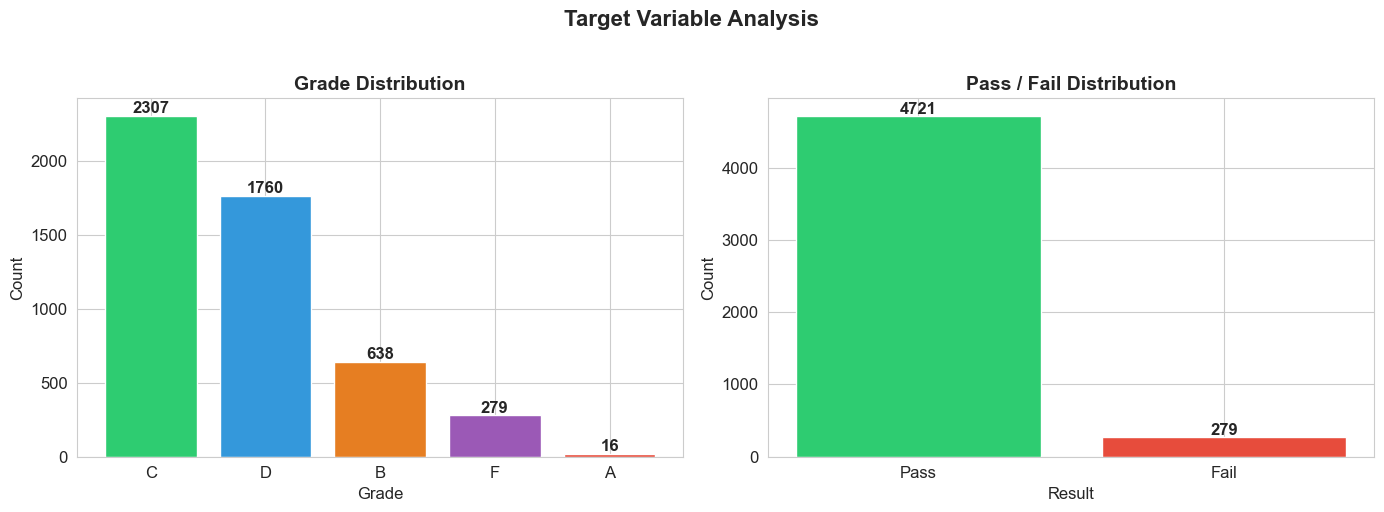

Passing rate: 94.4%  |  Failing rate: 5.6%


In [79]:
# Create Pass/Fail target: Grade F = Fail (0), anything else = Pass (1)
df['Pass_Fail'] = (df['Grade'] != 'F').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_counts = df['Grade'].value_counts()
colors_grade = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6', '#e74c3c']
axes[0].bar(grade_counts.index, grade_counts.values, color=colors_grade, edgecolor='white')
axes[0].set_title('Grade Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Count')
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

pf_counts = df['Pass_Fail'].value_counts()
axes[1].bar(['Pass', 'Fail'], [pf_counts[1], pf_counts[0]], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Pass / Fail Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Result')
axes[1].set_ylabel('Count')
axes[1].text(0, pf_counts[1] + 20, str(pf_counts[1]), ha='center', fontweight='bold')
axes[1].text(1, pf_counts[0] + 20, str(pf_counts[0]), ha='center', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Passing rate: {df["Pass_Fail"].mean()*100:.1f}%  |  Failing rate: {(1-df["Pass_Fail"].mean())*100:.1f}%')

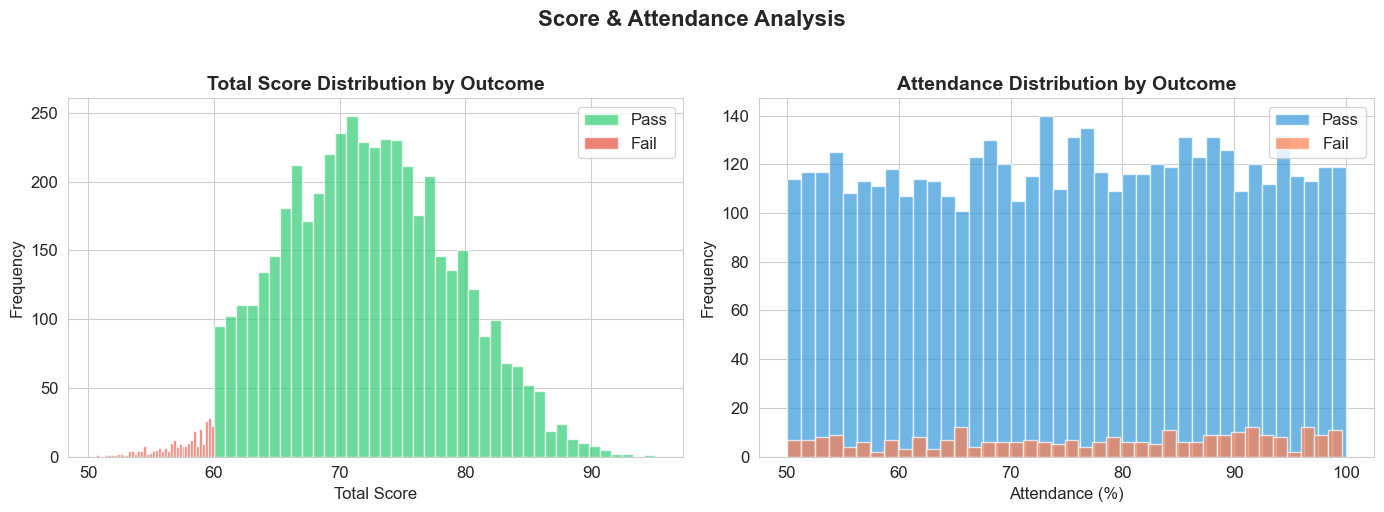

In [80]:
# Total Score distribution by Pass/Fail
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Pass_Fail']==1]['Total_Score'], bins=40, color='#2ecc71', alpha=0.7, label='Pass', edgecolor='white')
axes[0].hist(df[df['Pass_Fail']==0]['Total_Score'], bins=40, color='#e74c3c', alpha=0.7, label='Fail', edgecolor='white')
axes[0].set_title('Total Score Distribution by Outcome', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df[df['Pass_Fail']==1]['Attendance (%)'], bins=40, color='#3498db', alpha=0.7, label='Pass', edgecolor='white')
axes[1].hist(df[df['Pass_Fail']==0]['Attendance (%)'], bins=40, color='coral', alpha=0.7, label='Fail', edgecolor='white')
axes[1].set_title('Attendance Distribution by Outcome', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Score & Attendance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

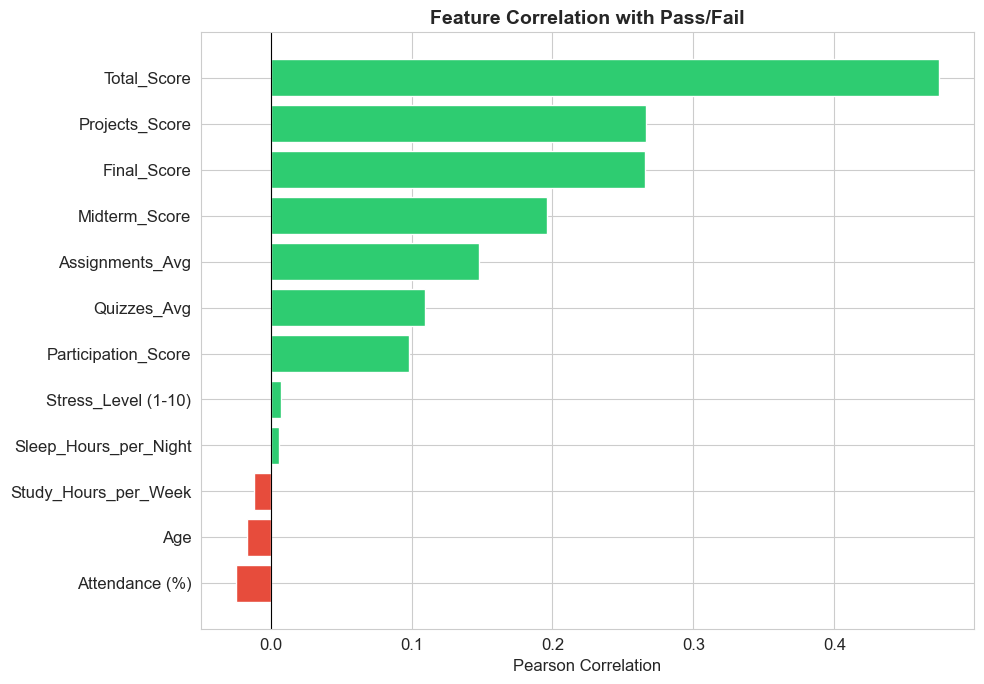

Key insight: Total_Score, Final_Score, and Midterm_Score are the strongest predictors!


In [81]:
# Top correlations with Pass_Fail
num_feats = df.select_dtypes(include='number').drop(columns=['Pass_Fail'])
corr = num_feats.corrwith(df['Pass_Fail']).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr.values]
plt.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Pass/Fail', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Key insight: Total_Score, Final_Score, and Midterm_Score are the strongest predictors!')

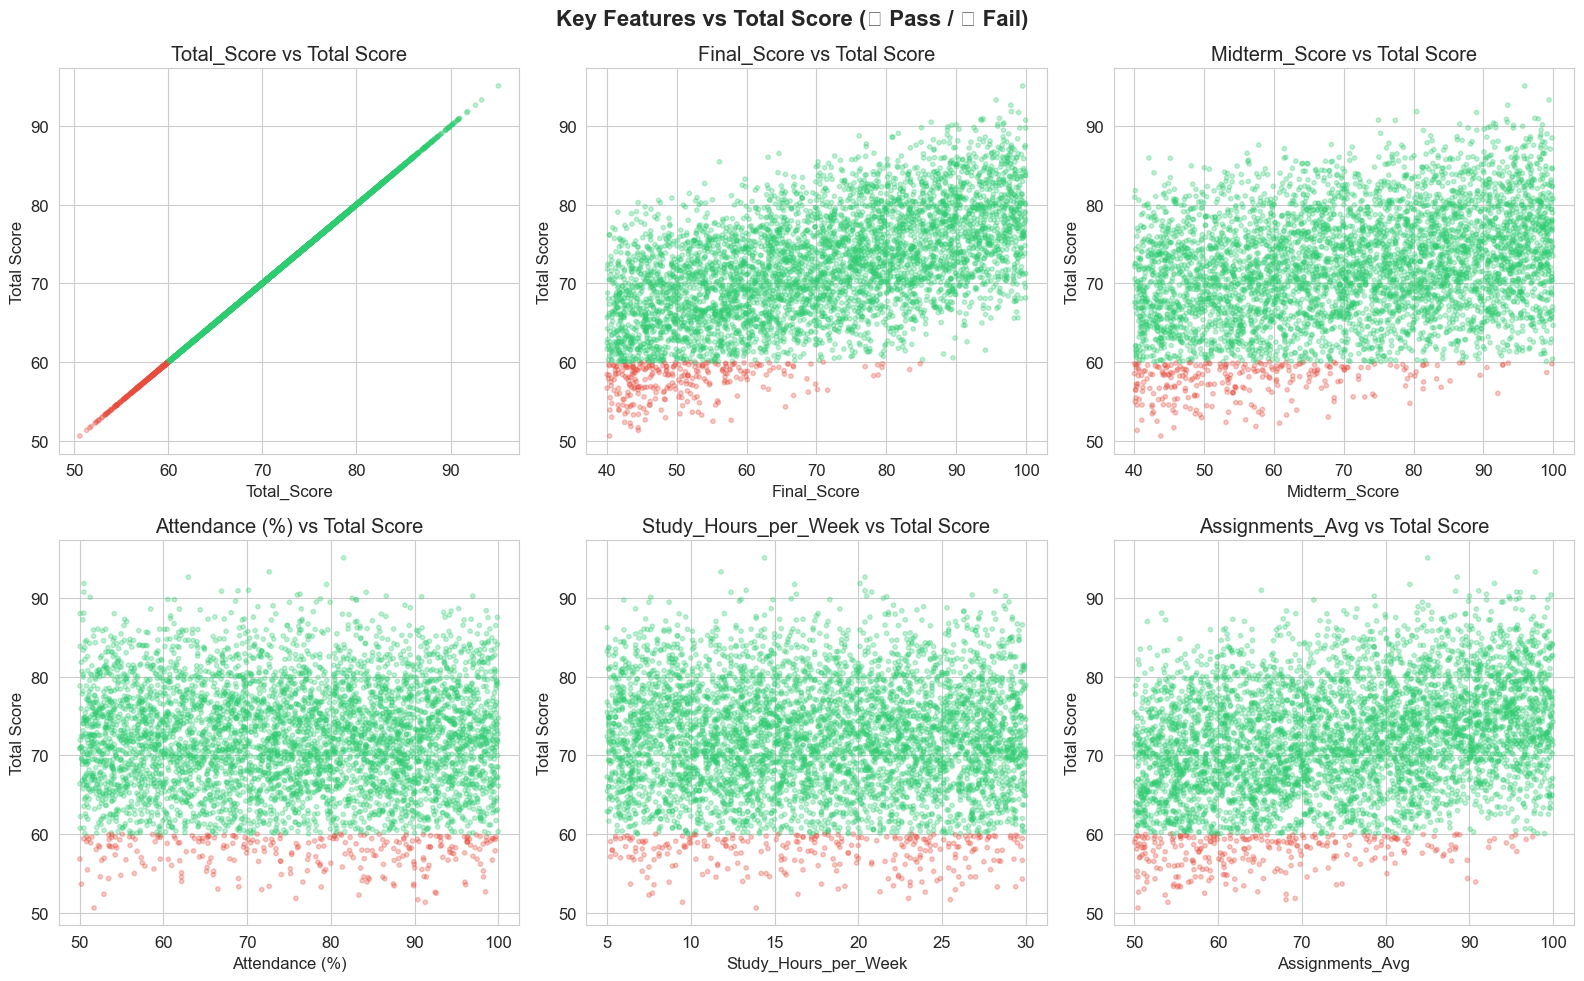

In [82]:
# Scatter plots for top features
top_features = ['Total_Score', 'Final_Score', 'Midterm_Score', 'Attendance (%)', 'Study_Hours_per_Week', 'Assignments_Avg']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, feat in enumerate(top_features):
    ax = axes[i // 3][i % 3]
    colors_map = df['Pass_Fail'].map({1: '#2ecc71', 0: '#e74c3c'})
    ax.scatter(df[feat], df['Total_Score'], alpha=0.3, c=colors_map, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('Total Score')
    ax.set_title(f'{feat} vs Total Score')

plt.suptitle('Key Features vs Total Score (🟢 Pass / 🔴 Fail)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

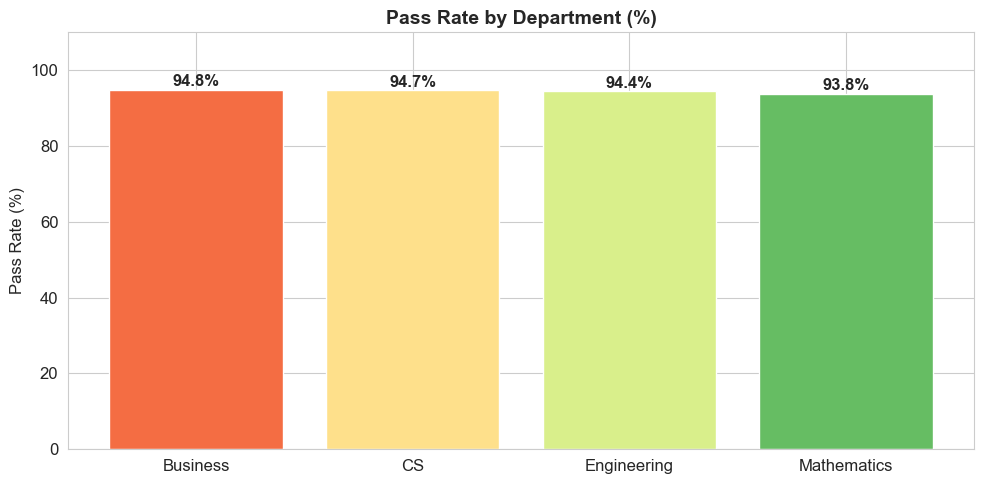

In [83]:
# Passing rate by Department
dept_pass = df.groupby('Department')['Pass_Fail'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
plt.bar(dept_pass.index, dept_pass.values,
        color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(dept_pass))))
plt.title('Pass Rate by Department (%)', fontsize=14, fontweight='bold')
plt.ylabel('Pass Rate (%)')
plt.ylim(0, 110)
for i, v in enumerate(dept_pass.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

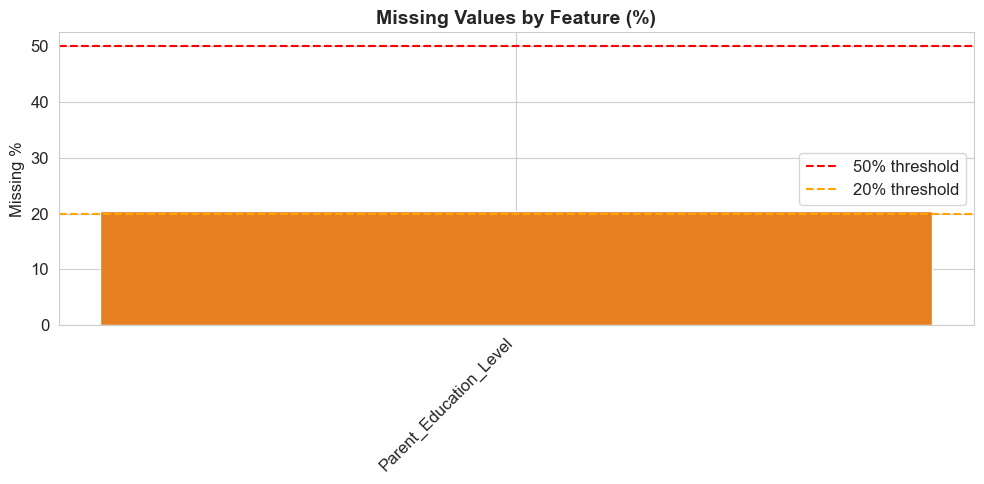

Missing value summary:
                        Count  Percentage
Parent_Education_Level   1025        20.5


In [84]:
# Missing values bar chart
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

plt.figure(figsize=(10, 5))
plt.bar(missing.index, missing_pct.values,
        color=['#e74c3c' if v > 50 else '#e67e22' if v > 20 else '#3498db' for v in missing_pct.values])
plt.axhline(50, color='red', linestyle='--', label='50% threshold')
plt.axhline(20, color='orange', linestyle='--', label='20% threshold')
plt.xticks(rotation=45, ha='right')
plt.title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
plt.ylabel('Missing %')
plt.legend()
plt.tight_layout()
plt.show()

print('Missing value summary:')
mv_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(mv_df)

### 4 - Data Preprocessing & Handling Missing Values

### Missing Value Strategy

Different features require different missing-value strategies:

- **Mode** for categorical features (most frequent value)
- **Median** for skewed numerical features
- **Drop** columns that are identifiers with no predictive value

This improves model robustness and preserves real-world meaning.

In [85]:
# STRATEGY 1: Drop non-predictive identifier columns
drop_cols = ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Grade']
df = df.drop(columns=drop_cols)

# STRATEGY 2: Categorical NaN → Mode (most frequent)
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f'  Filled {col} with mode: "{df[col].mode()[0]}"')

# STRATEGY 3: Numerical NaN → Median
num_cols = df.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'  Filled {col} with median: {df[col].median():.2f}')

print(f'\nMissing values remaining: {df.isnull().sum().sum()}')
print('All missing values are now handled!')

  Filled Parent_Education_Level with mode: "Bachelor's"

Missing values remaining: 0
All missing values are now handled!


In [86]:
# Feature Engineering — create new meaningful features
df['Score_Improvement']   = df['Final_Score'] - df['Midterm_Score']
df['Assignment_Quiz_Avg'] = (df['Assignments_Avg'] + df['Quizzes_Avg']) / 2
df['Engagement_Score']    = (df['Participation_Score'] + df['Projects_Score']) / 2
df['Sleep_Study_Ratio']   = df['Sleep_Hours_per_Night'] / (df['Study_Hours_per_Week'] + 1)
df['High_Attendance']     = (df['Attendance (%)'] >= 75).astype(int)
df['Low_Stress']          = (df['Stress_Level (1-10)'] <= 4).astype(int)

print('After feature engineering:')
print(f'New feature count is {df.shape[1]}')

After feature engineering:
New feature count is 25


In [87]:
# Encode categorical features
df_encoded = pd.get_dummies(df, drop_first=False)

print(df_encoded.shape)

(5000, 36)


In [88]:
# Separate features and target
X = df_encoded.drop(columns=['Pass_Fail'])
y = df_encoded['Pass_Fail']

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'Passing rate in train: {y_train.mean()*100:.1f}%')
print(f'Passing rate in val:   {y_val.mean()*100:.1f}%')

X_train: (4000, 35)
X_val:   (1000, 35)
Passing rate in train: 94.4%
Passing rate in val:   94.4%


### 5 - PCA — Dimensionality Reduction

Original Features : 35
PCA Features      : 20


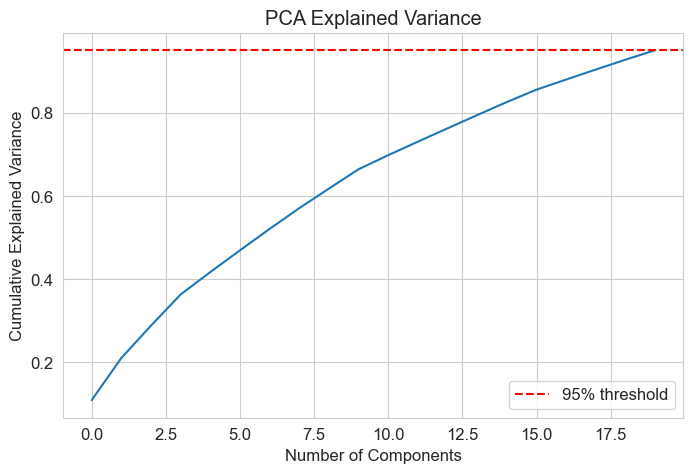

In [89]:
# Scale data
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Apply PCA while keeping 95% of variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)

# Print dimensions
print(f'Original Features : {X_train.shape[1]}')
print(f'PCA Features      : {X_train_pca.shape[1]}')

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.legend()
plt.grid(True)
plt.show()

## PART 2 — Model Training & Evaluation

In [90]:
# Helper evaluation function
def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl):
    model.fit(X_tr, y_tr)
    preds   = model.predict(X_vl)
    proba   = model.predict_proba(X_vl)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_vl, preds)
    auc  = roc_auc_score(y_vl, proba) if proba is not None else 0

    cv = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f'━━━ {name} ━━━')
    print(f'  Val Accuracy : {acc:.4f}')
    print(f'  Val ROC-AUC  : {auc:.4f}')
    print(f'  CV Accuracy  : {cv.mean():.4f} ± {cv.std():.4f}')
    print()
    return {'Model': name, 'Val Accuracy': acc, 'ROC-AUC': auc, 'CV Accuracy': cv.mean()}

results = []

In [91]:
# ─── MODEL 1: Logistic Regression (PCA) ───
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_pca, y_train)

lr_preds = lr.predict(X_val_pca)

lr_acc = accuracy_score(y_val, lr_preds)
lr_auc = roc_auc_score(y_val, lr.predict_proba(X_val_pca)[:, 1])

print('Logistic Regression (PCA)')
print(f'Accuracy : {lr_acc:.4f}')
print(f'ROC-AUC  : {lr_auc:.4f}')

Logistic Regression (PCA)
Accuracy : 0.9920
ROC-AUC  : 0.9995


In [92]:
# ─── MODEL 2: Random Forest ───
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=2,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)
r = evaluate_model('Random Forest', rf, X_train, y_train, X_val, y_val)
results.append(r)

━━━ Random Forest ━━━
  Val Accuracy : 1.0000
  Val ROC-AUC  : 1.0000
  CV Accuracy  : 0.9995 ± 0.0006



In [93]:
# ─── MODEL 3: XGBoost ───
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
r = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_val, y_val)
results.append(r)

━━━ XGBoost ━━━
  Val Accuracy : 1.0000
  Val ROC-AUC  : 1.0000
  CV Accuracy  : 0.9985 ± 0.0012



In [94]:
# ─── Model Comparison Table ───
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('Val Accuracy', ascending=False)

print('MODEL COMPARISON SUMMARY')

styled_table = (
    results_df.style
    .format("{:.4f}")
    .background_gradient(cmap='YlGn')
    .set_caption('Model Performance Comparison')
)

display(styled_table)

best_model_name = results_df.index[0]
print(f'\nBest Model: {best_model_name}')

MODEL COMPARISON SUMMARY


,Val Accuracy,ROC-AUC,CV Accuracy
Model,,,
Random Forest,1.0000,1.0000,0.9995
XGBoost,1.0000,1.0000,0.9985



Best Model: Random Forest


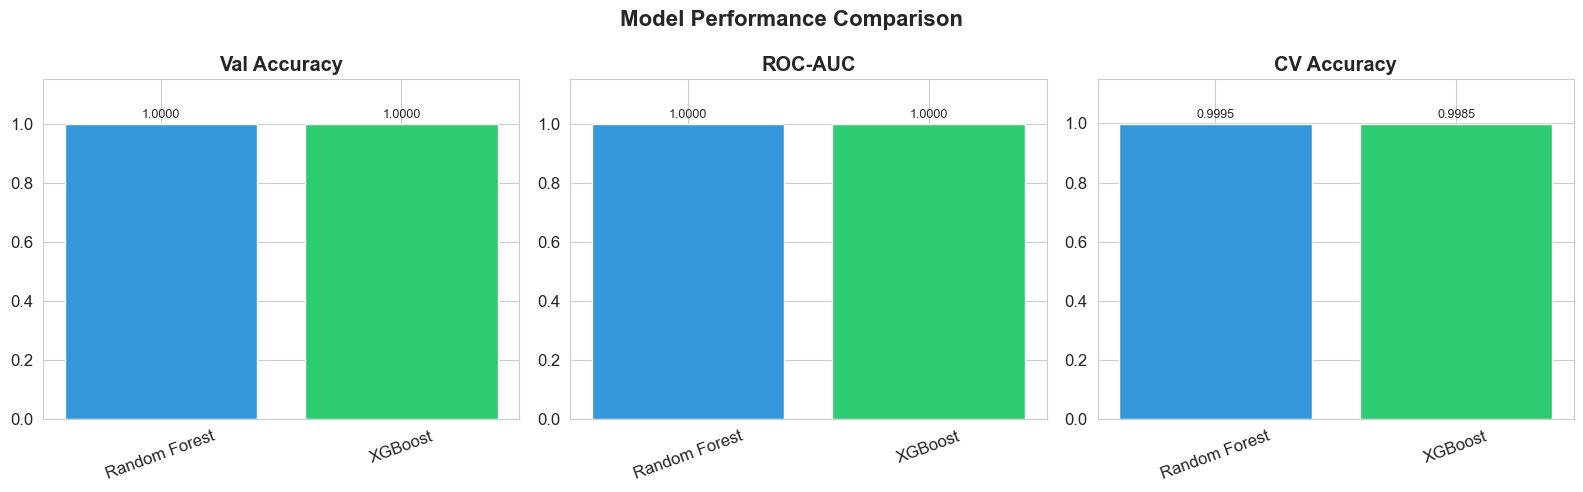

In [95]:
# ─── Model Comparison Bar Chart ───
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Val Accuracy', 'ROC-AUC', 'CV Accuracy']
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics):
    vals = results_df[metric]
    axes[i].bar(vals.index, vals.values, color=colors[:len(vals)])
    axes[i].set_title(metric, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].set_ylim(0, vals.max() * 1.15)
    for j, v in enumerate(vals.values):
        axes[i].text(j, v + vals.max() * 0.02, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [96]:
# Cross Validation Scores
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    scoring='accuracy',
    cv=5
)

print('Cross Validation Accuracy:')
print(np.round(cv_scores, 4))
print(f'Mean Accuracy: {cv_scores.mean():.4f}')

Cross Validation Accuracy:
[0.997 1.    0.999 1.    0.999]
Mean Accuracy: 0.9990


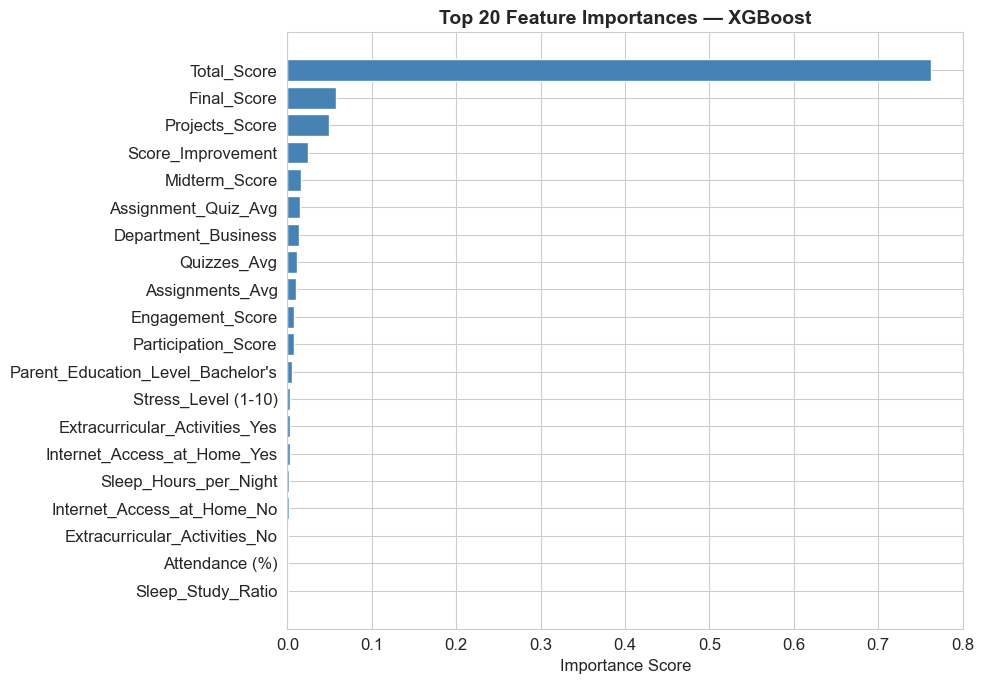

In [97]:
# ─── XGBoost Feature Importance ───
xgb_model.fit(X_train, y_train)
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

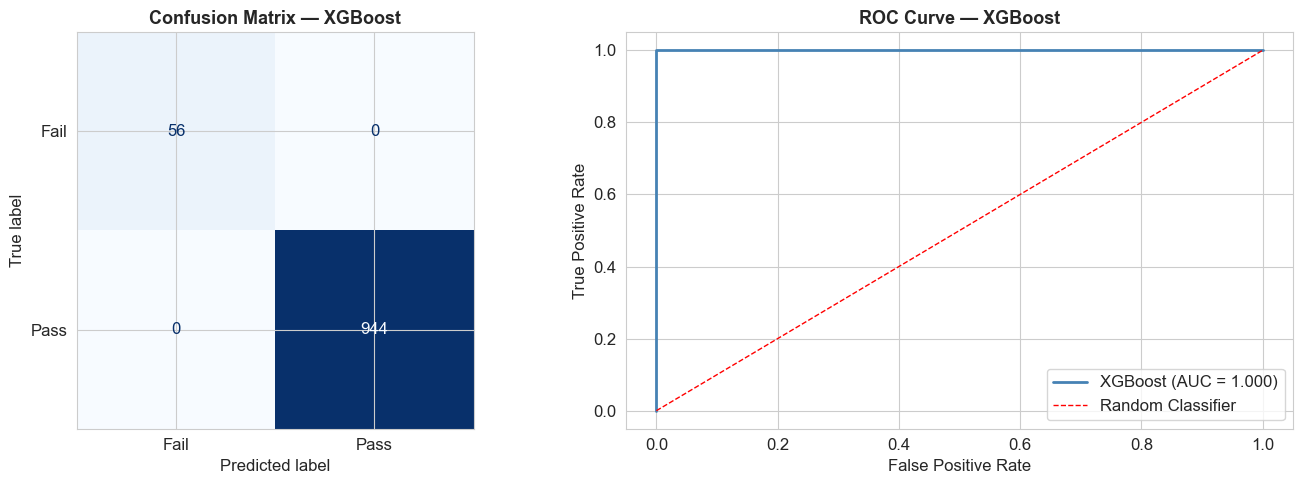

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        56
        Pass       1.00      1.00      1.00       944

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [98]:
# ─── Confusion Matrix ───
xgb_preds = xgb_model.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_val, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')

# ROC Curve
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, xgb_proba)
auc_score   = roc_auc_score(y_val, xgb_proba)

axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc_score:.3f})')
axes[1].plot([0,1],[0,1], 'r--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — XGBoost', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_val, xgb_preds, target_names=['Fail','Pass']))

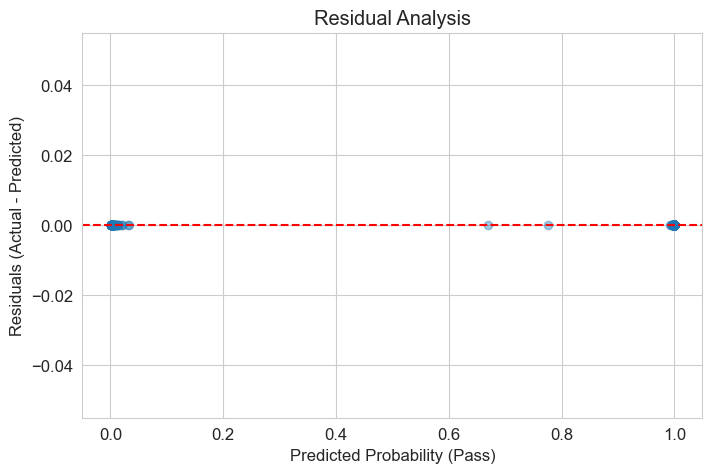

In [99]:
# Residual Analysis — Prediction Confidence Distribution
xgb_proba_all = xgb_model.predict_proba(X_val)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(xgb_proba_all, y_val - xgb_preds, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Probability (Pass)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Analysis')
plt.show()

In [100]:
# ─── Predict Result for a New Student ───
print('PREDICTING RESULT FOR A NEW STUDENT')

# Train final model on ALL data
xgb_final = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_final.fit(X, y)

# --- Define a new student manually ---
new_student_raw = pd.DataFrame([{
    'Gender'                     : 'Male',
    'Age'                        : 21,
    'Department'                 : 'CS',
    'Attendance (%)'             : 50.0,
    'Midterm_Score'              : 52.0,
    'Final_Score'                : 62.0,
    'Assignments_Avg'            : 73.0,
    'Quizzes_Avg'                : 79.0,
    'Participation_Score'        : 71.0,
    'Projects_Score'             : 61.0,
    'Total_Score'                : 73.0,
    'Study_Hours_per_Week'       : 21.0,
    'Extracurricular_Activities' : 'Yes',
    'Internet_Access_at_Home'    : 'Yes',
    'Parent_Education_Level'     : "Bachelor's",
    'Family_Income_Level'        : 'Medium',
    'Stress_Level (1-10)'        : 6,
    'Sleep_Hours_per_Night'      : 7.0,
}])

# Apply same feature engineering
new_student_raw['Score_Improvement']   = new_student_raw['Final_Score'] - new_student_raw['Midterm_Score']
new_student_raw['Assignment_Quiz_Avg'] = (new_student_raw['Assignments_Avg'] + new_student_raw['Quizzes_Avg']) / 2
new_student_raw['Engagement_Score']    = (new_student_raw['Participation_Score'] + new_student_raw['Projects_Score']) / 2
new_student_raw['Sleep_Study_Ratio']   = new_student_raw['Sleep_Hours_per_Night'] / (new_student_raw['Study_Hours_per_Week'] + 1)
new_student_raw['High_Attendance']     = (new_student_raw['Attendance (%)'] >= 75).astype(int)
new_student_raw['Low_Stress']          = (new_student_raw['Stress_Level (1-10)'] <= 4).astype(int)

# One-hot encode and align with training columns
new_student_enc = pd.get_dummies(new_student_raw)
new_student_enc = new_student_enc.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = xgb_final.predict(new_student_enc)[0]
probability = xgb_final.predict_proba(new_student_enc)[0]

result_label = 'PASS' if prediction == 1 else 'FAIL'

print(f'\n Prediction    : {result_label}')
print(f' Fail Probability : {probability[0]*100:.1f}%')
print(f' Pass Probability : {probability[1]*100:.1f}%')

PREDICTING RESULT FOR A NEW STUDENT

 Prediction    : PASS
 Fail Probability : 0.0%
 Pass Probability : 100.0%


## PART 3 — NLP: Entity Extraction from Egyptian Arabic

This module simulates an NLP pipeline that extracts student-related entities (name, grade, subject, score) from **Egyptian Arabic text** — such as WhatsApp messages or student report announcements in Arabic.

In [101]:
import re

class EgyptianStudentNLP:
    """
    Rule-based + regex NLP extractor for Egyptian Arabic academic text.
    Handles both Arabic numerals (١٢٣) and Western numerals (123).

    Entities extracted:
      - student_name : اسم الطالب
      - subject      : المادة الدراسية
      - score        : الدرجة
      - grade        : التقدير
      - result       : النتيجة (ناجح / راسب)
    """

    # ── Arabic to Western numeral map ──
    ARABIC_DIGITS = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')

    # ── Score keywords ──
    SCORE_KEYWORDS = [
        r'درجت[هو]?[:\s]*(\d+)',          # درجته: 75
        r'حصل على (\d+)',                  # حصل على 80
        r'(\d+)\s*(?:من|/)\s*100',        # 75 من 100
        r'نتيجت[هو]?[:\s]*(\d+)',         # نتيجته: 90
        r'score[:\s]*(\d+)',               # score: 85
        r'(\d+)\s*marks',                  # 90 marks
    ]

    # ── Subject keywords ──
    SUBJECTS = [
        'الرياضيات', 'الفيزياء', 'الكيمياء', 'الأحياء', 'اللغة العربية',
        'اللغة الإنجليزية', 'التاريخ', 'الجغرافيا', 'الحاسوب', 'البرمجة',
        'mathematics', 'physics', 'chemistry', 'biology', 'programming',
        'english', 'arabic', 'history', 'computer science', 'cs',
    ]

    # ── Result keywords ──
    PASS_KEYWORDS  = ['ناجح', 'اجتاز', 'نجح', 'passed', 'pass', 'ناجحة']
    FAIL_KEYWORDS  = ['راسب', 'رسب', 'فشل', 'failed', 'fail', 'راسبة']

    # ── Grade map ──
    GRADE_KEYWORDS = {
        'ممتاز': 'A', 'جيد جداً': 'B', 'جيد': 'C', 'مقبول': 'D', 'ضعيف': 'F',
        'A': 'A', 'B': 'B', 'C': 'C', 'D': 'D', 'F': 'F',
    }

    def normalize(self, text):
        text = text.translate(self.ARABIC_DIGITS)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def extract_score(self, text):
        for pattern in self.SCORE_KEYWORDS:
            m = re.search(pattern, text, re.IGNORECASE)
            if m:
                return int(m.group(1))
        return None

    def extract_subject(self, text):
        for subj in self.SUBJECTS:
            if subj.lower() in text.lower():
                return subj
        return None

    def extract_result(self, text):
        for kw in self.PASS_KEYWORDS:
            if kw in text:
                return 'Pass'
        for kw in self.FAIL_KEYWORDS:
            if kw in text:
                return 'Fail'
        return None

    def extract_grade(self, text):
        for arabic, letter in self.GRADE_KEYWORDS.items():
            if arabic in text:
                return letter
        return None

    def extract_name(self, text):
        m = re.search(r'(?:الطالب[ة]?|اسمه|اسمها)[:\s]+([\u0600-\u06FF]+(?:\s[\u0600-\u06FF]+)?)', text)
        if m:
            return m.group(1).strip()
        m = re.search(r'student[:\s]+([A-Za-z]+(?:\s[A-Za-z]+)?)', text, re.IGNORECASE)
        if m:
            return m.group(1).strip()
        return None

    def extract(self, raw_text):
        text = self.normalize(raw_text)
        return {
            'original_text': raw_text,
            'student_name'  : self.extract_name(text),
            'subject'       : self.extract_subject(text),
            'score'         : self.extract_score(text),
            'grade'         : self.extract_grade(text),
            'result'        : self.extract_result(text),
        }


# ── Demo ──
nlp = EgyptianStudentNLP()

In [102]:
# ─── Test on Egyptian Arabic student report messages ───
test_messages = [
    "الطالب أحمد محمد حصل على ٨٥ من 100 في الرياضيات وهو ناجح بتقدير جيد جداً",
    "الطالبة مريم سامي درجتها: 45 في الفيزياء وهي راسبة",
    "نتيجة الطالب كريم: 92 في البرمجة تقدير ممتاز وناجح",
    "الطالب يوسف أحمد في مادة الكيمياء درجته 38 من 100 وهو راسب",
    "الطالبة نور حسام حصلت على تقدير B في اللغة الإنجليزية وهي ناجحة",
    "Student Ahmed scored 90 marks in Computer Science — passed with grade A",
]

print('EGYPTIAN ARABIC NLP — ENTITY EXTRACTION RESULTS')

extracted_data = []
for i, msg in enumerate(test_messages, 1):
    result = nlp.extract(msg)
    extracted_data.append(result)

    print(f'\nMessage {i}: {msg}')
    print(f'  Name    : {result["student_name"] or "—"}')
    print(f'  Subject : {result["subject"] or "—"}')
    print(f'  Score   : {result["score"]}' if result['score'] is not None else '  Score   : —')
    print(f'  Grade   : {result["grade"] or "—"}')
    print(f'  Result  : {result["result"] or "—"}')

EGYPTIAN ARABIC NLP — ENTITY EXTRACTION RESULTS

Message 1: الطالب أحمد محمد حصل على ٨٥ من 100 في الرياضيات وهو ناجح بتقدير جيد جداً
  Name    : أحمد محمد
  Subject : الرياضيات
  Score   : 85
  Grade   : B
  Result  : Pass

Message 2: الطالبة مريم سامي درجتها: 45 في الفيزياء وهي راسبة
  Name    : مريم سامي
  Subject : الفيزياء
  Score   : —
  Grade   : —
  Result  : Fail

Message 3: نتيجة الطالب كريم: 92 في البرمجة تقدير ممتاز وناجح
  Name    : كريم
  Subject : البرمجة
  Score   : —
  Grade   : A
  Result  : Pass

Message 4: الطالب يوسف أحمد في مادة الكيمياء درجته 38 من 100 وهو راسب
  Name    : يوسف أحمد
  Subject : الكيمياء
  Score   : 38
  Grade   : —
  Result  : Fail

Message 5: الطالبة نور حسام حصلت على تقدير B في اللغة الإنجليزية وهي ناجحة
  Name    : نور حسام
  Subject : اللغة الإنجليزية
  Score   : —
  Grade   : B
  Result  : Pass

Message 6: Student Ahmed scored 90 marks in Computer Science — passed with grade A
  Name    : Ahmed scored
  Subject : computer science
  Score   : 

In [103]:
# ─── NLP Results as DataFrame ───
nlp_df = pd.DataFrame(extracted_data).drop('original_text', axis=1)
print('\nExtracted Entities Summary:')
print(nlp_df.to_string())


Extracted Entities Summary:
   student_name           subject  score grade result
0     أحمد محمد         الرياضيات   85.0     B   Pass
1     مريم سامي          الفيزياء    NaN   NaN   Fail
2          كريم           البرمجة    NaN     A   Pass
3     يوسف أحمد          الكيمياء   38.0   NaN   Fail
4      نور حسام  اللغة الإنجليزية    NaN     B   Pass
5  Ahmed scored  computer science   90.0     A   Pass


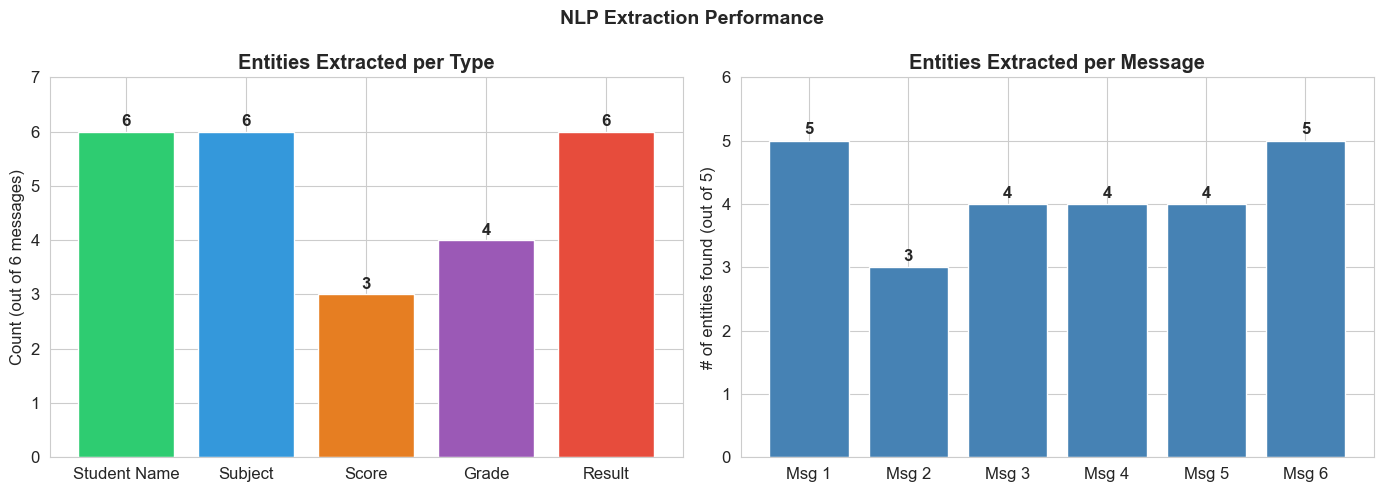

In [104]:
# ─── NLP Entity Extraction Coverage Chart ───
entity_cols   = ['student_name', 'subject', 'score', 'grade', 'result']
entity_labels = ['Student Name', 'Subject', 'Score', 'Grade', 'Result']
extracted_counts = nlp_df[entity_cols].notna().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(entity_labels, extracted_counts.values,
            color=['#2ecc71', '#3498db', '#e67e22', '#9b59b6', '#e74c3c'])
axes[0].set_title('Entities Extracted per Type', fontweight='bold')
axes[0].set_ylabel(f'Count (out of {len(test_messages)} messages)')
axes[0].set_ylim(0, len(test_messages) + 1)
for i, v in enumerate(extracted_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

completeness = nlp_df[entity_cols].notna().sum(axis=1)
axes[1].bar([f'Msg {i+1}' for i in range(len(completeness))],
            completeness.values, color='steelblue')
axes[1].set_title('Entities Extracted per Message', fontweight='bold')
axes[1].set_ylabel('# of entities found (out of 5)')
axes[1].set_ylim(0, 6)
for i, v in enumerate(completeness.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('NLP Extraction Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()